# Federated Medical Diagnosis Support System
## Training Notebook — NIH ChestX-ray14

Dataset layout detected on disk:
```
data/nih_xray/
  images_1/                    <- flat PNGs (~10,000 images)
  images_2/                    <- flat PNGs (~10,000 images)
  Data_Entry_2017_v2020.csv    <- original NIH CSV (112,120 rows)
  multilabel_dataset.csv       <- pre-processed with 14 binary columns
  train/<disease>/             <- class-organised pre-split subset
  test/<disease>/              <- class-organised pre-split subset
```

This notebook walks through:
1. Dataset preparation and exploration
2. Single-hospital model training (ResNet50 & ViT)
3. Class-folder dataset training (train/ test/ splits)
4. Federated learning simulation (3 hospitals)
5. Differential privacy training
6. Model evaluation and metrics
7. GradCAM explainability
8. RAG knowledge base demo
9. Full AI diagnosis agent demo

In [11]:
# ── Environment setup ──────────────────────────────────────────────────────
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

print(f'PyTorch version : {torch.__version__}')
print(f'CUDA available  : {torch.cuda.is_available()}')
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device    : {device}')

PyTorch version : 2.7.1+cu118
CUDA available  : True
Using device    : cuda


## 1. Dataset Configuration
Paths are auto-detected from the actual dataset layout. No manual edits needed.

In [12]:
from data.dataset import (
    DEFAULT_CSV, DEFAULT_IMG_DIRS, NIH_ROOT, DISEASE_LABELS
)

# Auto-detected paths — verified against actual layout
CSV_PATH   = str(DEFAULT_CSV)      # multilabel_dataset.csv (pre-processed)
IMAGE_DIRS = DEFAULT_IMG_DIRS      # [images_1, images_2]

print(f'CSV       : {CSV_PATH}')
print(f'Image dirs: {IMAGE_DIRS}')
print(f'NIH root  : {NIH_ROOT}')

# Training hyperparameters
BATCH_SIZE        = 32
NUM_EPOCHS        = 10
LEARNING_RATE     = 1e-4
SUBSET_FRACTION   = 0.1   # 10% for quick experiments; set 1.0 for full training
NUM_HOSPITALS     = 3
FEDERATED_ROUNDS  = 5
LOCAL_EPOCHS      = 2

CSV       : D:\projects\hos_sys\data\nih_xray\multilabel_dataset.csv
Image dirs: ['D:\\projects\\hos_sys\\data\\nih_xray\\images_1', 'D:\\projects\\hos_sys\\data\\nih_xray\\images_2']
NIH root  : D:\projects\hos_sys\data\nih_xray


## 2. Explore the Dataset

In [13]:
from data.dataset import ChestXrayDataset, get_dataloader

# Load a small subset for exploration (uses multilabel_dataset.csv by default)
train_loader, train_dataset = get_dataloader(
    split           = 'train',
    batch_size      = BATCH_SIZE,
    num_workers     = 0,          # 0 = main process (safe on Windows)
    subset_fraction = SUBSET_FRACTION,
)

print(f'Training samples : {len(train_dataset)}')
print(f'Disease labels   : {DISEASE_LABELS}')

[ChestXrayDataset] Cached 14,999 images.
[ChestXrayDataset] split=train | samples=1045 | csv=multilabel_dataset.csv
Training samples : 1045
Disease labels   : ['Atelectasis', 'Cardiomegaly', 'Effusion', 'Infiltration', 'Mass', 'Nodule', 'Pneumonia', 'Pneumothorax', 'Consolidation', 'Edema', 'Emphysema', 'Fibrosis', 'Pleural_Thickening', 'Hernia']


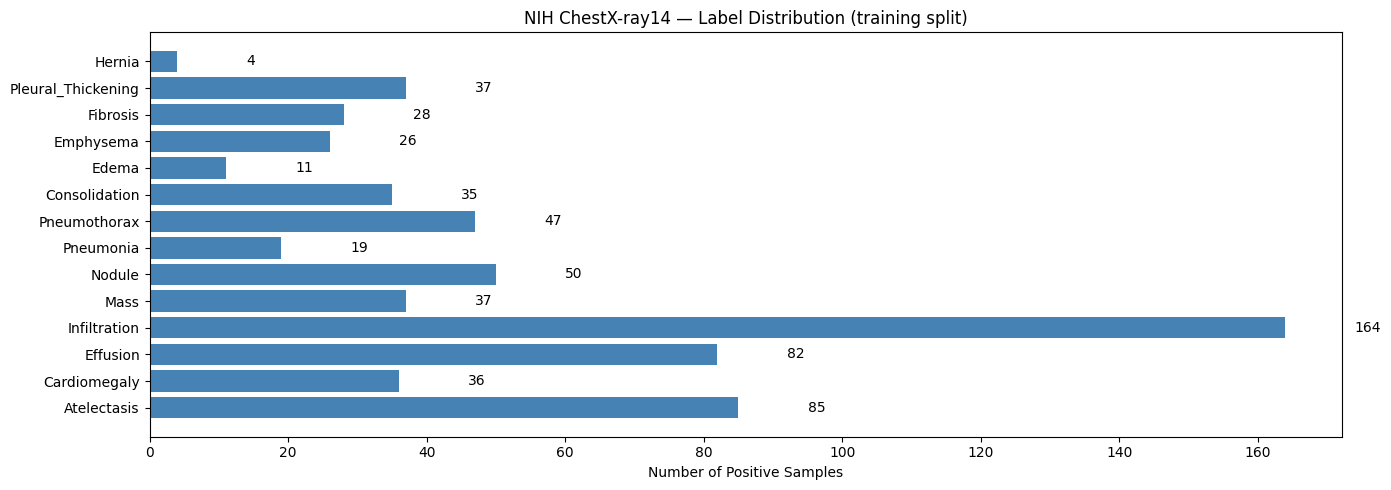

In [14]:
# ── Label distribution ─────────────────────────────────────────────────────
label_counts = train_dataset.get_label_counts()

fig, ax = plt.subplots(figsize=(14, 5))
diseases = list(label_counts.keys())
counts   = list(label_counts.values())

bars = ax.barh(diseases, counts, color='steelblue')
ax.set_xlabel('Number of Positive Samples')
ax.set_title('NIH ChestX-ray14 — Label Distribution (training split)')
for bar, count in zip(bars, counts):
    ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
            str(count), va='center')
plt.tight_layout()
plt.show()

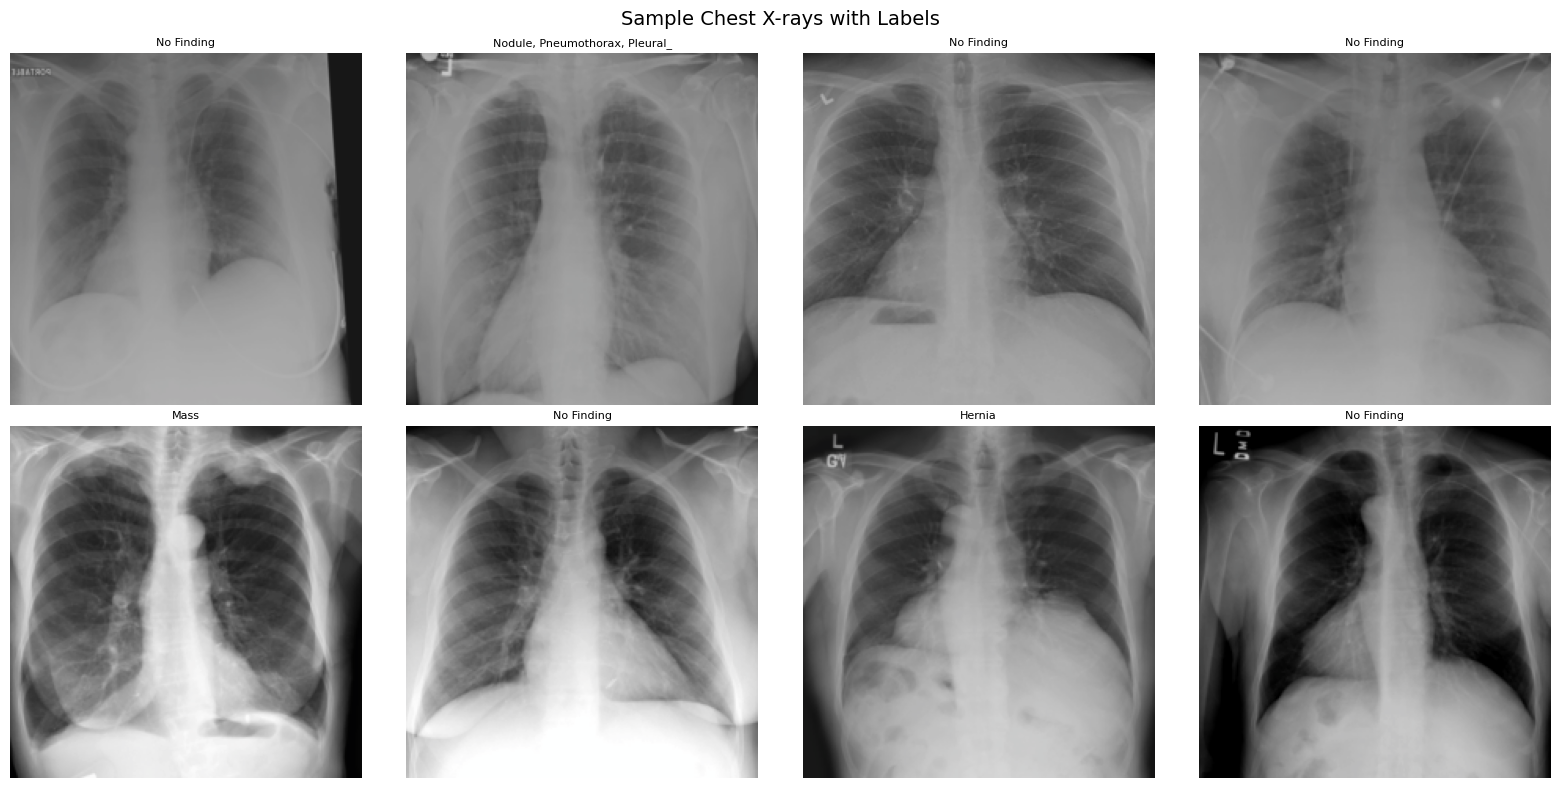

In [15]:
# ── Sample images from the dataset ────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])

for i, (img_tensor, label_vec) in enumerate(train_dataset):
    if i >= 8: break
    img = img_tensor.permute(1, 2, 0).numpy()
    img = (img * std + mean).clip(0, 1)
    
    diseases_present = [DISEASE_LABELS[j] for j, v in enumerate(label_vec) if v > 0]
    title = ', '.join(diseases_present) if diseases_present else 'No Finding'
    
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(title[:30], fontsize=8)
    axes[i].axis('off')

plt.suptitle('Sample Chest X-rays with Labels', fontsize=14)
plt.tight_layout()
plt.show()

## 2b. Class-Folder Dataset (train/ and test/ splits)
The dataset also has pre-organised class folders at `nih_xray/train/<disease>/`.

In [16]:
from data.dataset import ClassFolderDataset, get_folder_dataloader

# Load from the class-folder split
folder_train_loader, folder_train_ds = get_folder_dataloader(
    split='train', batch_size=BATCH_SIZE, num_workers=0
)
folder_test_loader, folder_test_ds = get_folder_dataloader(
    split='test', batch_size=BATCH_SIZE, num_workers=0
)

print(f'Folder train samples : {len(folder_train_ds)}')
print(f'Folder test  samples : {len(folder_test_ds)}')

# Label distribution in folder split
all_labels = torch.stack([lv for _, lv in folder_train_ds.samples])
print('\nFolder train label counts:')
for i, d in enumerate(DISEASE_LABELS):
    print(f'  {d:<22}: {int(all_labels[:, i].sum())}')

[ClassFolderDataset] split=train | classes=15 | samples=3354
[ClassFolderDataset] split=test | classes=15 | samples=821
Folder train samples : 3354
Folder test  samples : 821

Folder train label counts:
  Atelectasis           : 150
  Cardiomegaly          : 61
  Effusion              : 133
  Infiltration          : 336
  Mass                  : 49
  Nodule                : 85
  Pneumonia             : 15
  Pneumothorax          : 75
  Consolidation         : 52
  Edema                 : 14
  Emphysema             : 45
  Fibrosis              : 71
  Pleural_Thickening    : 47
  Hernia                : 15


## 3. Train ResNet-50 (Single Hospital)

In [17]:
from models.resnet_model import build_resnet
import torch.nn as nn
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR
from sklearn.metrics import roc_auc_score, f1_score
from tqdm import tqdm

# Build model
model = build_resnet(num_classes=14, pretrained=True)
model = model.to(device)

# Positive class weights to handle label imbalance
pos_weights = train_dataset.get_pos_weights().to(device)
criterion   = nn.BCEWithLogitsLoss(pos_weight=pos_weights)
optimizer   = Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
scheduler   = CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

# Validation loader
val_loader, val_dataset = get_dataloader(
    split='val', batch_size=BATCH_SIZE,
    num_workers=0, subset_fraction=SUBSET_FRACTION
)

print(f'Model parameters: {sum(p.numel() for p in model.parameters()):,}')

[ResNet] Parameters — total: 24,564,302  trainable: 24,564,302
[ChestXrayDataset] Cached 14,999 images.
[ChestXrayDataset] split=val | samples=244 | csv=multilabel_dataset.csv
Model parameters: 24,564,302


In [18]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    for images, labels in tqdm(loader, leave=False):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(images)
        loss   = criterion(logits, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_probs, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            logits = model(images)
            total_loss += criterion(logits, labels).item()
            all_probs.append(torch.sigmoid(logits).cpu())
            all_labels.append(labels.cpu())
    probs  = torch.cat(all_probs).numpy()
    labels = torch.cat(all_labels).numpy()
    try:
        auc = roc_auc_score(labels, probs, average='macro')
    except Exception:
        auc = 0.0
    f1 = f1_score(labels, probs >= 0.5, average='macro', zero_division=0)
    return total_loss / len(loader), auc, f1

In [19]:
# ── Training loop ──────────────────────────────────────────────────────────
history = {'train_loss': [], 'val_loss': [], 'val_auc': [], 'val_f1': []}

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_auc, val_f1 = evaluate(model, val_loader, criterion, device)
    scheduler.step()
    
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_auc'].append(val_auc)
    history['val_f1'].append(val_f1)
    
    print(f'Epoch {epoch:2d}/{NUM_EPOCHS} | '
          f'train_loss={train_loss:.4f} | '
          f'val_loss={val_loss:.4f} | '
          f'val_AUC={val_auc:.4f} | '
          f'val_F1={val_f1:.4f}')

os.makedirs('../models', exist_ok=True)
torch.save({'model_state_dict': model.state_dict(), 'history': history},
           '../models/resnet_trained.pth')
print('Model saved to ../models/resnet_trained.pth')

d:\projects\cuda\Lib\site-packages\sklearn\metrics\_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


Epoch  1/10 | train_loss=1.3067 | val_loss=1.2761 | val_AUC=nan | val_F1=0.0642


d:\projects\cuda\Lib\site-packages\sklearn\metrics\_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


Epoch  2/10 | train_loss=1.3145 | val_loss=1.2652 | val_AUC=nan | val_F1=0.0454


d:\projects\cuda\Lib\site-packages\sklearn\metrics\_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


...

Epoch  8/10 | train_loss=1.1301 | val_loss=1.2948 | val_AUC=nan | val_F1=0.1270


d:\projects\cuda\Lib\site-packages\sklearn\metrics\_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


Epoch  9/10 | train_loss=1.1010 | val_loss=1.2874 | val_AUC=nan | val_F1=0.1205


d:\projects\cuda\Lib\site-packages\sklearn\metrics\_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


Epoch 10/10 | train_loss=1.1034 | val_loss=1.2941 | val_AUC=nan | val_F1=0.1266
Model saved to ../models/resnet_trained.pth


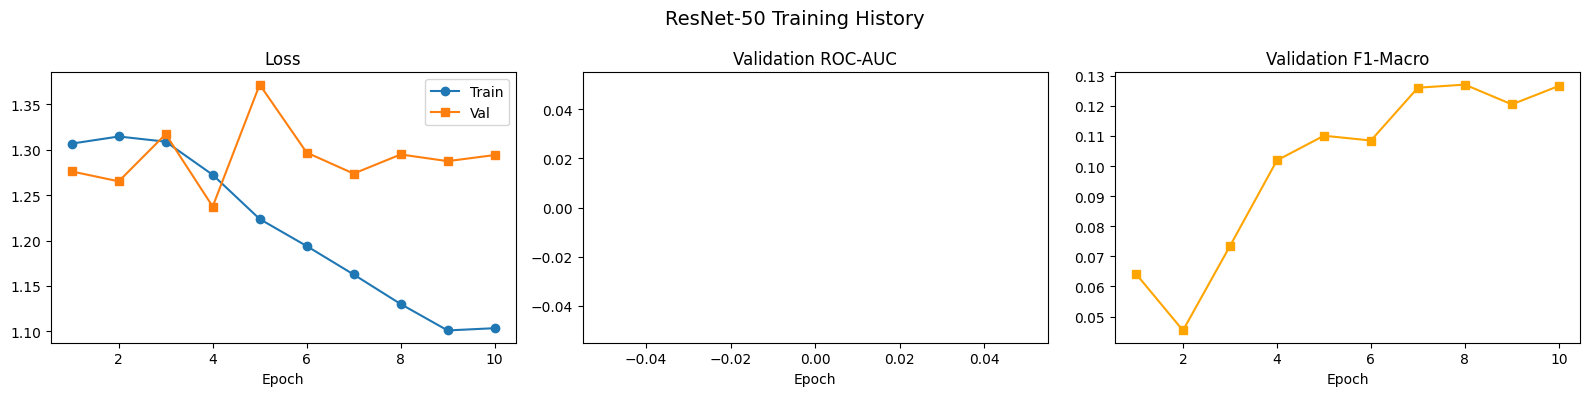

In [20]:
# ── Plot training curves ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
ep = range(1, NUM_EPOCHS + 1)

axes[0].plot(ep, history['train_loss'], label='Train', marker='o')
axes[0].plot(ep, history['val_loss'],   label='Val',   marker='s')
axes[0].set_title('Loss'); axes[0].legend(); axes[0].set_xlabel('Epoch')

axes[1].plot(ep, history['val_auc'], color='green', marker='o')
axes[1].set_title('Validation ROC-AUC'); axes[1].set_xlabel('Epoch')

axes[2].plot(ep, history['val_f1'], color='orange', marker='s')
axes[2].set_title('Validation F1-Macro'); axes[2].set_xlabel('Epoch')

plt.suptitle('ResNet-50 Training History', fontsize=14)
plt.tight_layout()
plt.show()

## 4. Train Vision Transformer (ViT-Base)

In [21]:
from models.vit_model import build_vit

# Freeze backbone; only train last 4 transformer blocks + head
vit_model = build_vit(num_classes=14, pretrained=True, unfreeze_last_n=4)
vit_model = vit_model.to(device)

vit_optimizer = Adam(
    filter(lambda p: p.requires_grad, vit_model.parameters()),
    lr=5e-5, weight_decay=1e-4
)

print('ViT model ready.')
print('Use the same train_one_epoch / evaluate functions with vit_model.')
# Example: train_one_epoch(vit_model, train_loader, vit_optimizer, criterion, device)

[ViT] Parameters — total: 86,000,654  trainable: 28,553,486
ViT model ready.
Use the same train_one_epoch / evaluate functions with vit_model.


## 5. Federated Learning Simulation

In [22]:
from hospital_nodes.local_training import HospitalNode, train_local_model
from federated_server.fedavg import FederatedServer

global_model = build_resnet(num_classes=14, pretrained=True)
server       = FederatedServer(global_model, save_dir='../models/federated')

# Each hospital gets a non-overlapping subset (different random seed)
hospital_nodes = []
for i in range(NUM_HOSPITALS):
    node = HospitalNode(
        hospital_id     = f'Hospital_{chr(65+i)}',
        model           = global_model,
        batch_size      = BATCH_SIZE,
        num_workers     = 0,
        subset_fraction = SUBSET_FRACTION / NUM_HOSPITALS,
        seed            = i * 42,
        # csv_path and image_dirs auto-detected from dataset module
    )
    hospital_nodes.append(node)

print(f'Created {NUM_HOSPITALS} hospital nodes.')

[ResNet] Parameters — total: 24,564,302  trainable: 24,564,302
[FederatedServer] Initialised. Save dir: ../models/federated
[ChestXrayDataset] Cached 14,999 images.
[ChestXrayDataset] split=train | samples=340 | csv=multilabel_dataset.csv
[ChestXrayDataset] Cached 14,999 images.
[ChestXrayDataset] split=val | samples=78 | csv=multilabel_dataset.csv
[Hospital_A] Device=cuda | Train=340 | Val=78
[ChestXrayDataset] Cached 14,999 images.
[ChestXrayDataset] split=train | samples=343 | csv=multilabel_dataset.csv
[ChestXrayDataset] Cached 14,999 images.
[ChestXrayDataset] split=val | samples=82 | csv=multilabel_dataset.csv
[Hospital_B] Device=cuda | Train=343 | Val=82
[ChestXrayDataset] Cached 14,999 images.
[ChestXrayDataset] split=train | samples=348 | csv=multilabel_dataset.csv
[ChestXrayDataset] Cached 14,999 images.
[ChestXrayDataset] split=val | samples=75 | csv=multilabel_dataset.csv
[Hospital_C] Device=cuda | Train=348 | Val=75
Created 3 hospital nodes.


In [23]:
fed_history = []

for round_idx in range(1, FEDERATED_ROUNDS + 1):
    print(f'\n=== Federated Round {round_idx}/{FEDERATED_ROUNDS} ===')
    global_weights = server.get_global_weights()
    updates = []
    
    for node in hospital_nodes:
        w, n, metrics = train_local_model(
            node, global_weights, local_epochs=LOCAL_EPOCHS
        )
        updates.append((w, n, metrics))
    
    server.aggregate(updates)
    fed_history.append(server.history[-1])

server.print_history()
server.save_checkpoint('global_final.pth')


=== Federated Round 1/5 ===


d:\projects\cuda\Lib\site-packages\sklearn\metrics\_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
d:\projects\cuda\Lib\site-packages\sklearn\metrics\_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
d:\projects\cuda\Lib\site-packages\sklearn\metrics\_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


[Hospital_A] Local training done — val_loss=1.1354  auc=nan  f1=0.0285


d:\projects\cuda\Lib\site-packages\sklearn\metrics\_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
d:\projects\cuda\Lib\site-packages\sklearn\metrics\_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


[Hospital_B] Local training done — val_loss=1.3371  auc=nan  f1=0.0384


...

d:\projects\cuda\Lib\site-packages\sklearn\metrics\_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
d:\projects\cuda\Lib\site-packages\sklearn\metrics\_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


[Hospital_B] Local training done — val_loss=1.5167  auc=nan  f1=0.0119


d:\projects\cuda\Lib\site-packages\sklearn\metrics\_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


[Hospital_C] Local training done — val_loss=2.0733  auc=nan  f1=0.0143
[FederatedServer] Round 5 complete | clients=3 | avg_auc=nan | avg_f1=0.0087

 Round   Clients   Samples       AUC        F1
--------------------------------------------------
     1         3      1031       nan    0.0357
     2         3      1031       nan    0.0381
     3         3      1031       nan    0.0308
     4         3      1031       nan    0.0090
     5         3      1031       nan    0.0087
[FederatedServer] Saved checkpoint → ../models/federated\global_final.pth


'../models/federated\\global_final.pth'

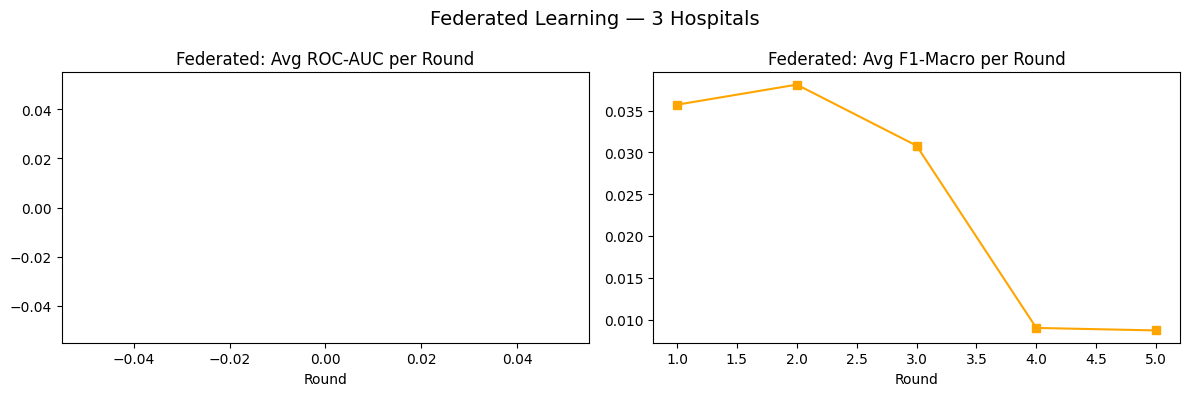

In [24]:
rounds   = [h['round']   for h in fed_history]
avg_aucs = [h['avg_auc'] for h in fed_history]
avg_f1s  = [h['avg_f1']  for h in fed_history]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(rounds, avg_aucs, marker='o', color='dodgerblue')
ax1.set_title('Federated: Avg ROC-AUC per Round'); ax1.set_xlabel('Round')

ax2.plot(rounds, avg_f1s, marker='s', color='orange')
ax2.set_title('Federated: Avg F1-Macro per Round'); ax2.set_xlabel('Round')

plt.suptitle(f'Federated Learning — {NUM_HOSPITALS} Hospitals', fontsize=14)
plt.tight_layout()
plt.show()

## 6. Differential Privacy Training

In [25]:
from privacy.differential_privacy import DifferentialPrivacyTrainer

dp_model     = build_resnet(num_classes=14, pretrained=True).to(device)
dp_optimizer = Adam(dp_model.parameters(), lr=LEARNING_RATE)

dp_trainer = DifferentialPrivacyTrainer(
    model            = dp_model,
    optimizer        = dp_optimizer,
    dataloader       = train_loader,
    max_grad_norm    = 1.0,
    noise_multiplier = 1.1,
    delta            = 1e-5,
    backend          = 'manual',
    device           = device,
)

dp_criterion = nn.BCEWithLogitsLoss()
for dp_epoch in range(1, 4):
    m = dp_trainer.train_epoch(dp_criterion)
    print(f'DP Epoch {dp_epoch}: loss={m["loss"]:.4f} | ε={m["epsilon"]:.4f} | δ={m["delta"]:.1e}')

print('\n' + dp_trainer.get_dp_summary())

[ResNet] Parameters — total: 24,564,302  trainable: 24,564,302
[DP] Backend=manual | max_grad_norm=1.0 | noise_multiplier=1.1
DP Epoch 1: loss=0.7003 | ε=0.7629 | δ=1.0e-05
DP Epoch 2: loss=0.7000 | ε=1.0790 | δ=1.0e-05
DP Epoch 3: loss=0.7003 | ε=1.3215 | δ=1.0e-05

DP Guarantee: (ε=1.3215, δ=1.0e-05)
  Steps completed : 96
  Noise multiplier: 1.1
  Max grad norm   : 1.0
  Sample rate     : 0.0306
  Interpretation  : Moderate privacy


## 7. GradCAM Explainability

[ChestXrayDataset] Cached 14,999 images.
[ChestXrayDataset] split=test | samples=20 | csv=multilabel_dataset.csv
True labels: ['No Finding']


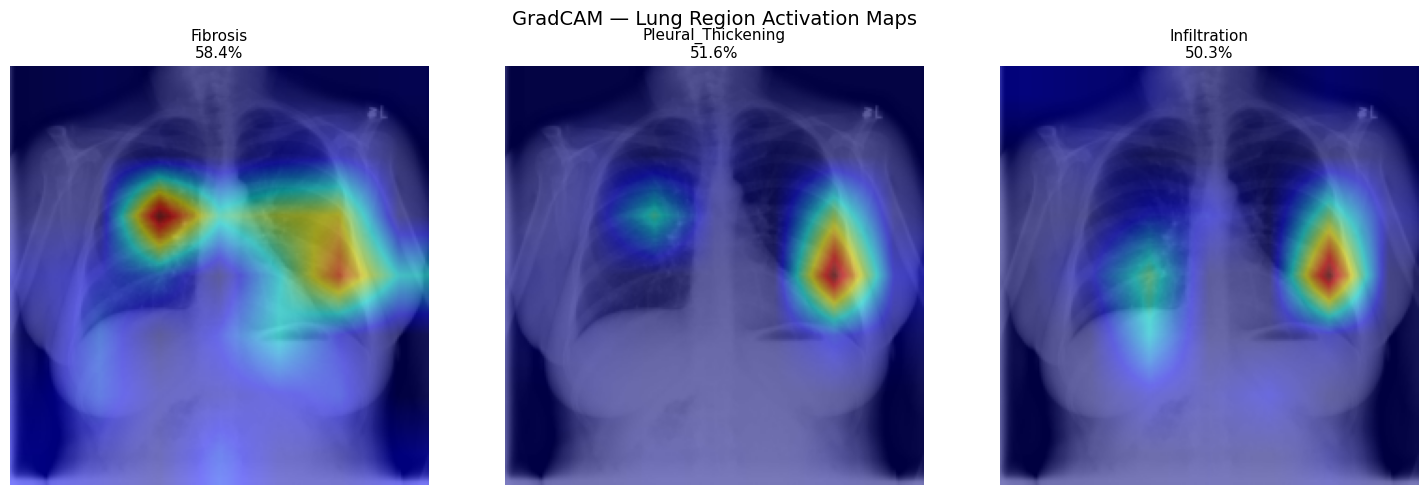

In [26]:
from explainability.gradcam import generate_multi_class_heatmaps

# Use a single image from the test split
test_loader, _ = get_dataloader(split='test', batch_size=1, num_workers=0, subset_fraction=0.01)
sample_img, sample_label = next(iter(test_loader))

true_diseases = [DISEASE_LABELS[i] for i, v in enumerate(sample_label[0]) if v > 0]
print(f'True labels: {true_diseases or ["No Finding"]}')

# Generate GradCAM for top-3 predicted diseases
model.eval()
gradcam_results = generate_multi_class_heatmaps(
    model=model, image_tensor=sample_img,
    disease_labels=DISEASE_LABELS, top_k=3,
)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (disease, prob, heatmap, overlay) in zip(axes, gradcam_results):
    ax.imshow(overlay)
    ax.set_title(f'{disease}\n{prob*100:.1f}%', fontsize=11)
    ax.axis('off')

plt.suptitle('GradCAM — Lung Region Activation Maps', fontsize=14)
plt.tight_layout()
plt.show()

## 8. RAG Knowledge Base Demo

In [27]:
from rag.knowledge_base import MedicalKnowledgeBase

kb = MedicalKnowledgeBase(use_faiss=True)

results = kb.query('chest pain cough fever treatment', top_k=3)
print('Top RAG results:')
for r in results:
    print(f'  [{r["disease"]} — {r["aspect"]}] score={r["score"]:.3f}')
    print(f'  {r["content"][:100]}...')
    print()

# Disease-specific lookup
info = kb.get_disease_info('Pneumonia')
print('Pneumonia treatment:')
for step in info.get('treatment', []):
    print(f'  - {step}')

[RAG] WARNING: No module named 'faiss' — falling back to keyword search.
Top RAG results:
  [Infiltration — symptoms] score=4.000
  Productive cough; Fever; Dyspnea; Pleuritic chest pain; Haemoptysis...

  [Pneumonia — symptoms] score=4.000
  High fever and chills; Productive cough with purulent sputum; Chest pain on breathing; Dyspnea; Fati...

  [Consolidation — symptoms] score=4.000
  Cough with purulent or bloody sputum; High fever; Pleuritic chest pain; Bronchial breath sounds on a...

Pneumonia treatment:
  - Antibiotics (amoxicillin or macrolide for community-acquired)
  - Hospitalisation if severe (PSI/CURB-65 score)
  - Supplemental oxygen
  - IV fluids and supportive care
  - Antiviral agents for viral pneumonia


## 9. Full AI Diagnosis Agent Demo

In [28]:
from agent.diagnosis_agent import DiagnosisAgent

agent = DiagnosisAgent(
    model=model, knowledge_base=kb,
    threshold=0.40, model_name='ResNet-50 (Federated)', device=device,
)

report = agent.diagnose(sample_img, patient_id='PT-DEMO-001')
print(agent.format_report(report))

────────────────────────────────────────────────────────────
  AI DIAGNOSTIC REPORT — Patient: PT-DEMO-001
────────────────────────────────────────────────────────────
  Model        : ResNet-50 (Federated)
  Urgency      : ROUTINE

  IMPRESSION
  AI model (ResNet-50 (Federated)) indicates probable **Fibrosis** (58.4%). Additional findings: Pleural_Thickening (51.6%), Infiltration (50.3%), Nodule (42.2%). — Routine clinical evaluation suggested

  DETECTED CONDITIONS
  1. Fibrosis                  Prob:  58.4%  |  Severity: moderate
  2. Pleural_Thickening        Prob:  51.6%  |  Severity: moderate
  3. Infiltration              Prob:  50.3%  |  Severity: low
  4. Nodule                    Prob:  42.2%  |  Severity: low

  RECOMMENDED ACTIONS
   1. Anti-fibrotic agents: pirfenidone or nintedanib
   2. Supplemental oxygen
   3. Pulmonary rehabilitation
   4. Management of underlying cause
   5. Decortication surgery for significant restriction
   6. Antibiotics for bacterial infection
 

In [29]:
# Probability table
rows = agent.get_probability_table(report)
df   = pd.DataFrame(rows, columns=['Disease', 'Probability (%)', 'Severity'])
df.style.background_gradient(subset=['Probability (%)'], cmap='RdYlGn_r')

,Disease,Probability (%),Severity
0,Fibrosis,58.440000,moderate
1,Pleural_Thickening,51.620000,moderate
2,Infiltration,50.330000,low
3,Nodule,42.230000,low
4,Pneumothorax,37.720000,low
5,Mass,37.260000,low
6,Atelectasis,33.270000,low
7,Consolidation,31.630000,low
8,Effusion,31.480000,low
9,Cardiomegaly,28.740000,low


## 10. Per-class ROC Curves

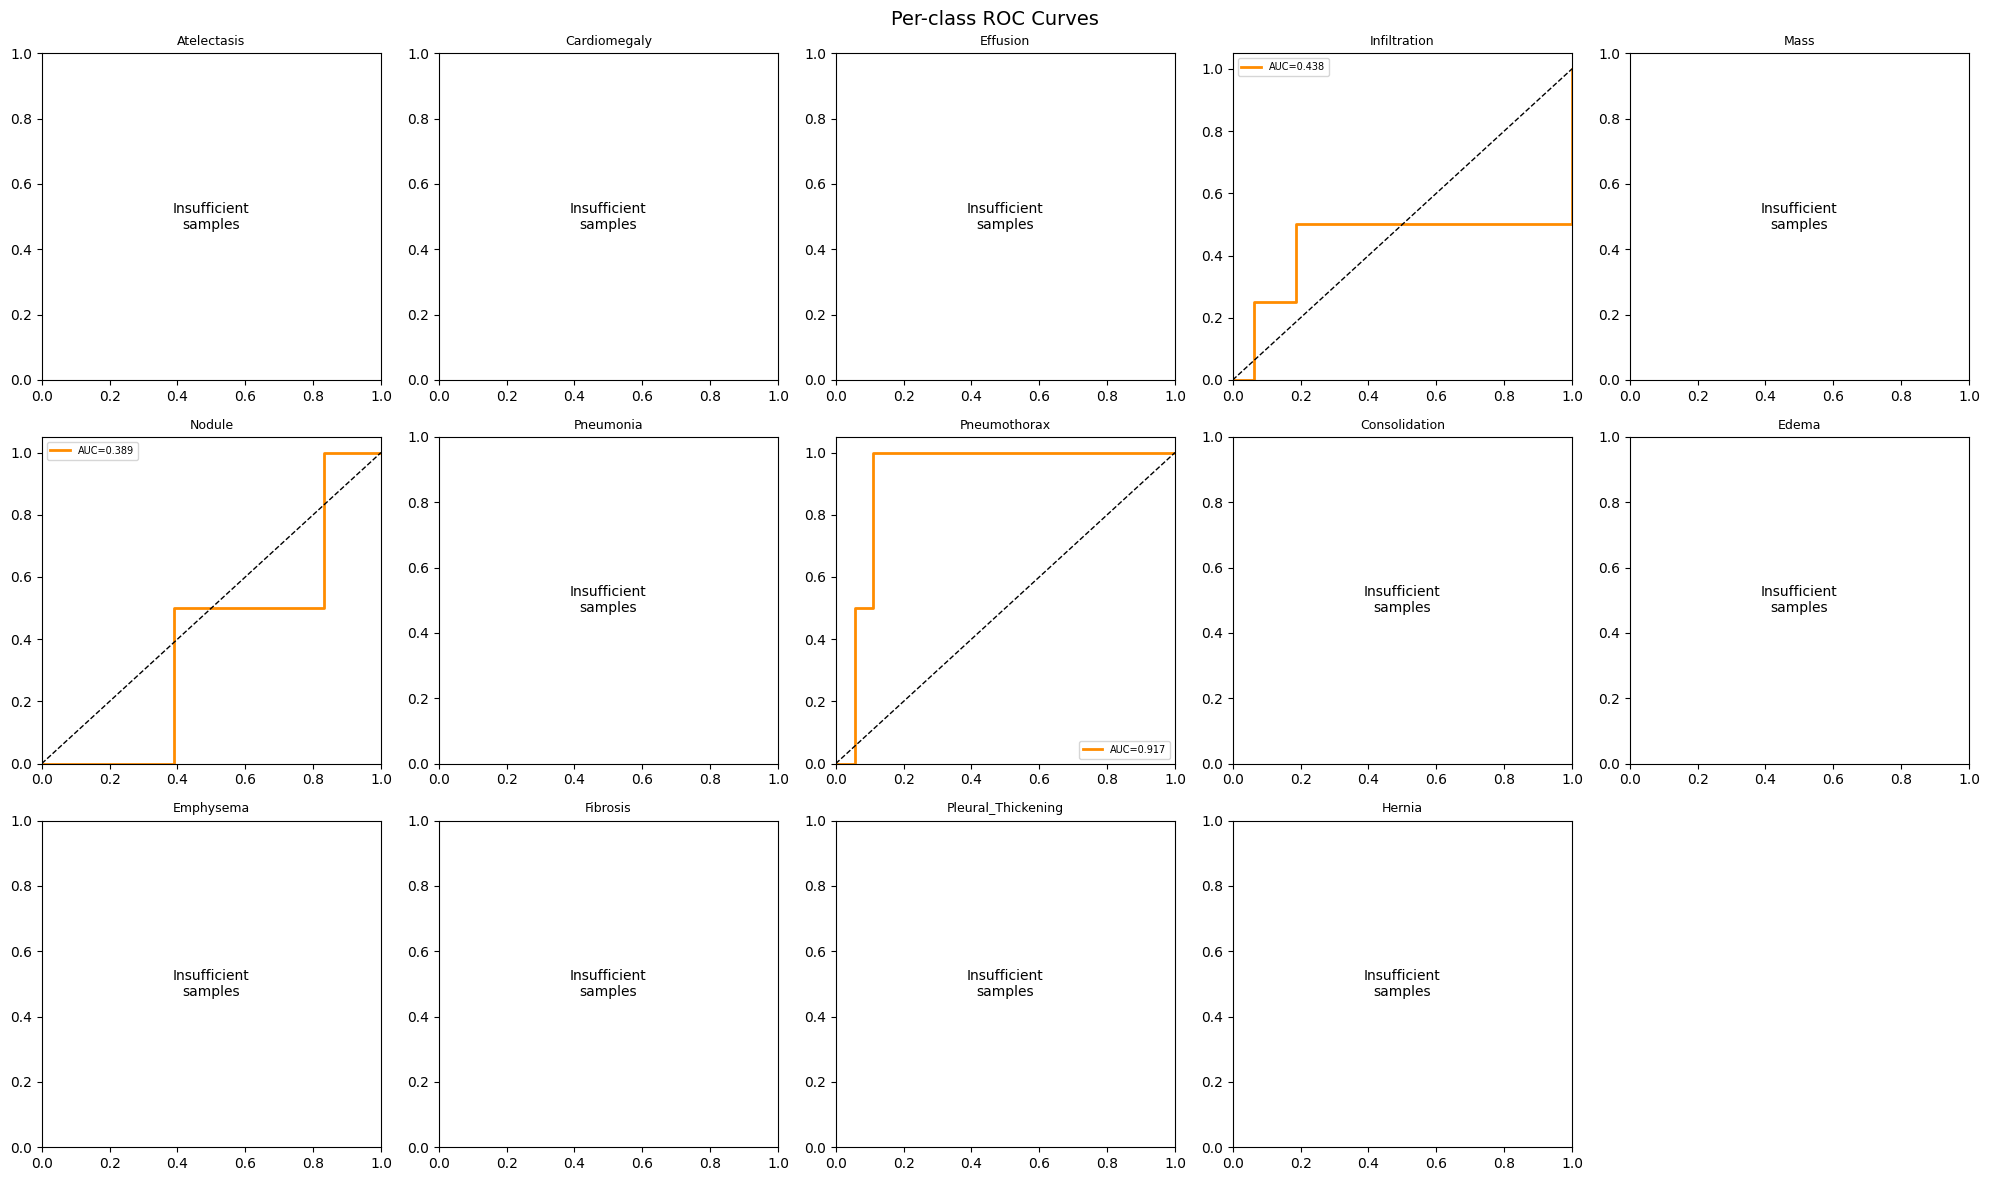

In [30]:
from sklearn.metrics import roc_curve, auc as sklearn_auc

model.eval()
all_probs, all_labels = [], []

with torch.no_grad():
    for imgs, lbls in test_loader:
        probs = torch.sigmoid(model(imgs.to(device))).cpu()
        all_probs.append(probs)
        all_labels.append(lbls)

all_probs  = torch.cat(all_probs).numpy()
all_labels = torch.cat(all_labels).numpy()

fig, axes = plt.subplots(3, 5, figsize=(20, 12))
axes = axes.flatten()

for i, disease in enumerate(DISEASE_LABELS):
    if all_labels[:, i].sum() < 2:
        axes[i].text(0.5, 0.5, 'Insufficient\nsamples',
                     ha='center', va='center', transform=axes[i].transAxes)
        axes[i].set_title(disease, fontsize=9)
        continue
    fpr, tpr, _ = roc_curve(all_labels[:, i], all_probs[:, i])
    roc_auc     = sklearn_auc(fpr, tpr)
    axes[i].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC={roc_auc:.3f}')
    axes[i].plot([0, 1], [0, 1], 'k--', lw=1)
    axes[i].set_xlim([0, 1]); axes[i].set_ylim([0, 1.05])
    axes[i].set_title(disease, fontsize=9)
    axes[i].legend(fontsize=7)

for j in range(len(DISEASE_LABELS), len(axes)):
    axes[j].axis('off')

plt.suptitle('Per-class ROC Curves', fontsize=14)
plt.tight_layout()
plt.show()

## 11. Launch Dashboard

```bash
# From the project root:
streamlit run dashboard/app.py
```

Optional — pass a trained checkpoint via the sidebar:
```
models/federated/global_final.pth
```

## 12. CLI Federated Training

```bash
# Auto-detected paths (recommended):
python run_federated.py --num-hospitals 3 --num-rounds 10

# With differential privacy:
python run_federated.py --num-hospitals 3 --num-rounds 10 --use-dp
```

## 13. Docker

```bash
docker build -f docker/Dockerfile -t medical-ai-system .
docker run -p 8501:8501 \
  -v %cd%/data:/app/data \
  -v %cd%/models:/app/models \
  medical-ai-system
```